In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import warnings
from typing import List
import os

%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import scipy 
import random
from os.path import dirname, join

In [2]:
import scipy

In [3]:
sns.set_style('white')

In [4]:
import PyComplexHeatmap
from PyComplexHeatmap import *

In [5]:
sc.settings.verbosity = 3 
sc.settings.set_figure_params(dpi=100, dpi_save=300, facecolor='white', figsize=(4,4))

In [8]:
adata_fibro =sc.write_h5ad('./data/adata_fibro.h5ad')

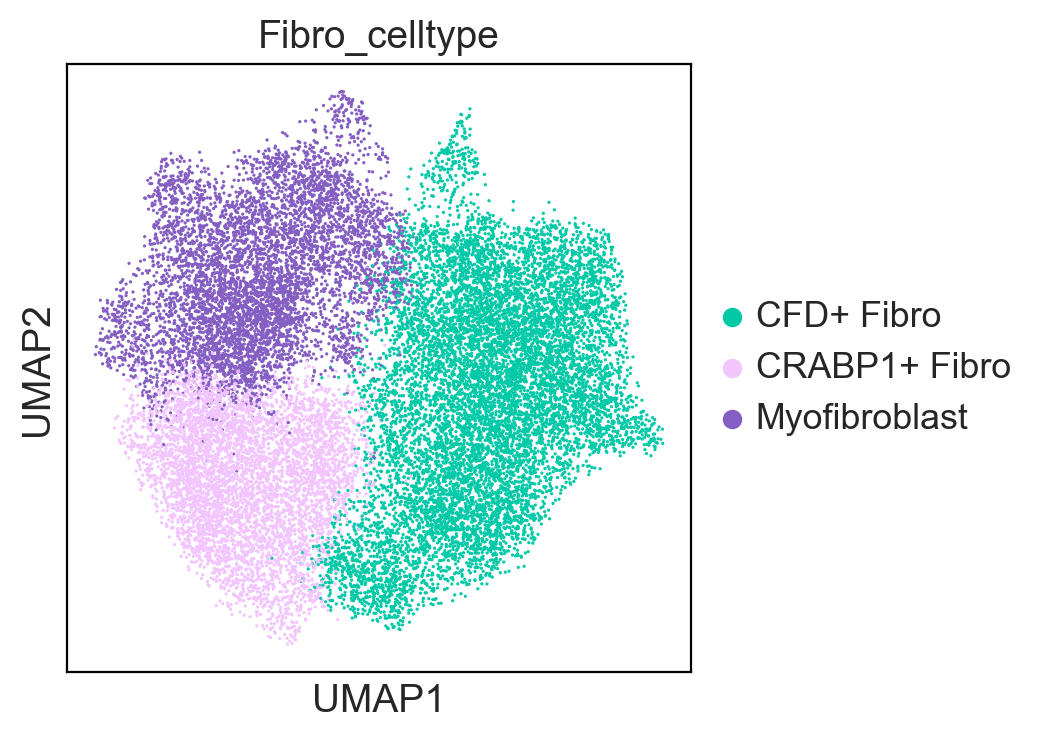

In [10]:
sc.pl.umap(adata_fibro, color= 'Fibro_celltype')

In [14]:
DR = pd.read_csv('./Monocle2_dim_reduction.csv', index_col=0)
DR = DR.T
DR.columns = ['Component1', 'Component2']
DR = DR.loc[adata_fibro.obs_names,]
adata_fibro.obsm['X_Monocle2_DR'] = DR.values

In [18]:
pdata = pd.read_csv('./pdata_DEG_600.csv', index_col=0)
adata_fibro.obs['Pseudotime'] = pdata.loc[adata_fibro.obs_names, 'Pseudotime']

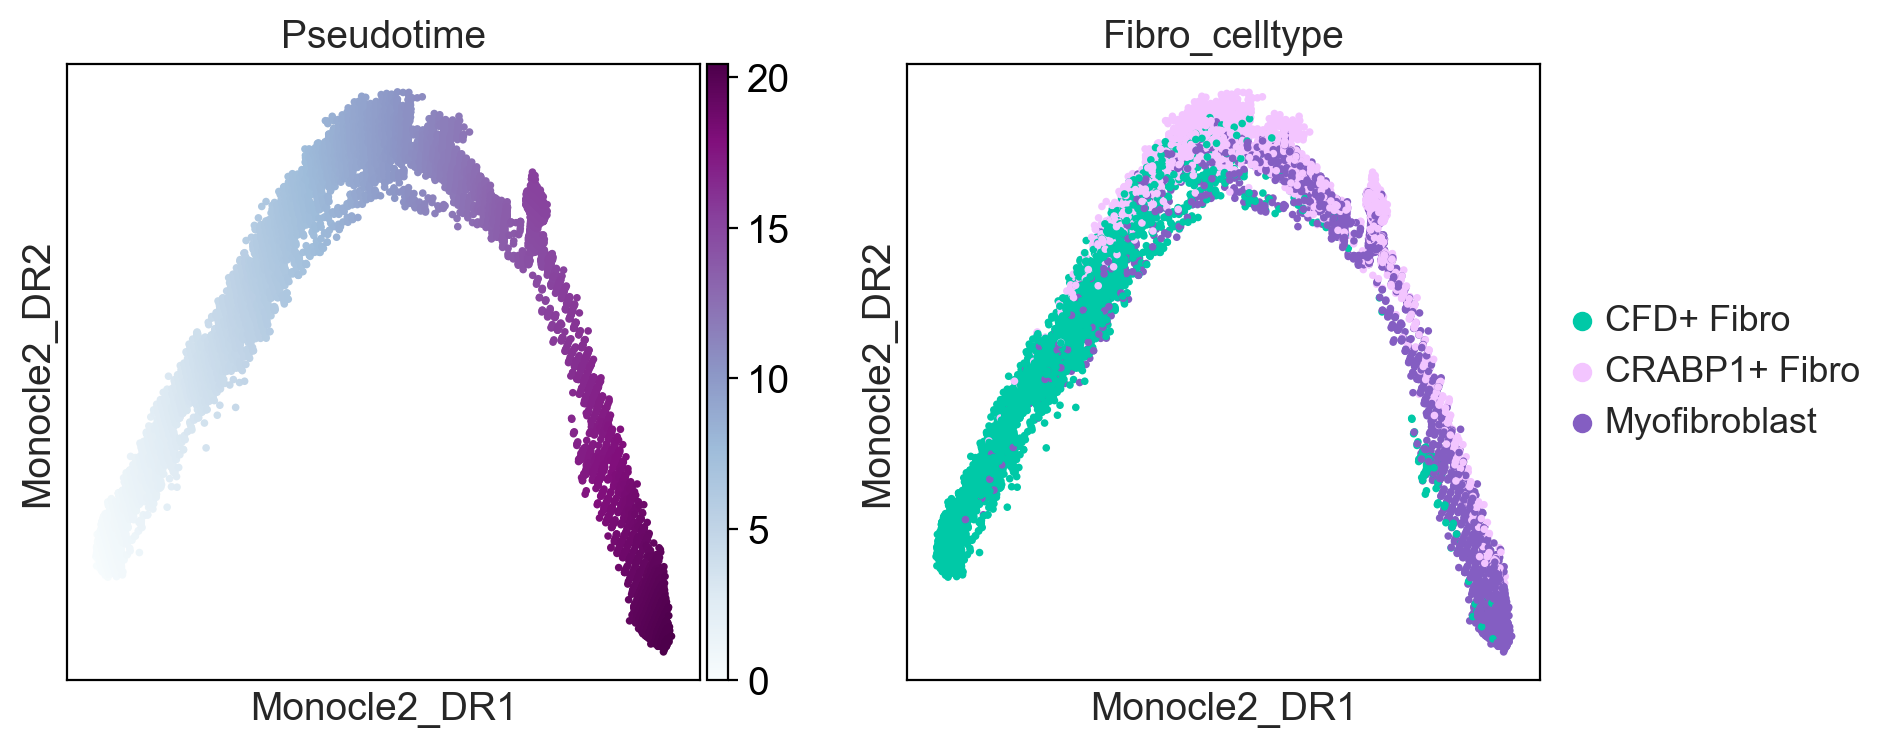

In [19]:
sc.pl.embedding(adata_fibro, basis='Monocle2_DR', color=['Pseudotime', 'Fibro_celltype'], cmap='BuPu',size=30)

In [65]:
import joypy

In [71]:
data = adata_fibro.obs[['Pseudotime', 'Fibro_celltype']]

In [79]:
from matplotlib.colors import LinearSegmentedColormap
colors =   ['#C4C4C4',  '#93579f']              
n_bins = [0,  1]
cmap_name = 'my_colormap'
cm = LinearSegmentedColormap.from_list(cmap_name, list(zip(n_bins, colors)))

Text(0.5, 1.0, 'Density ridgeline plot')

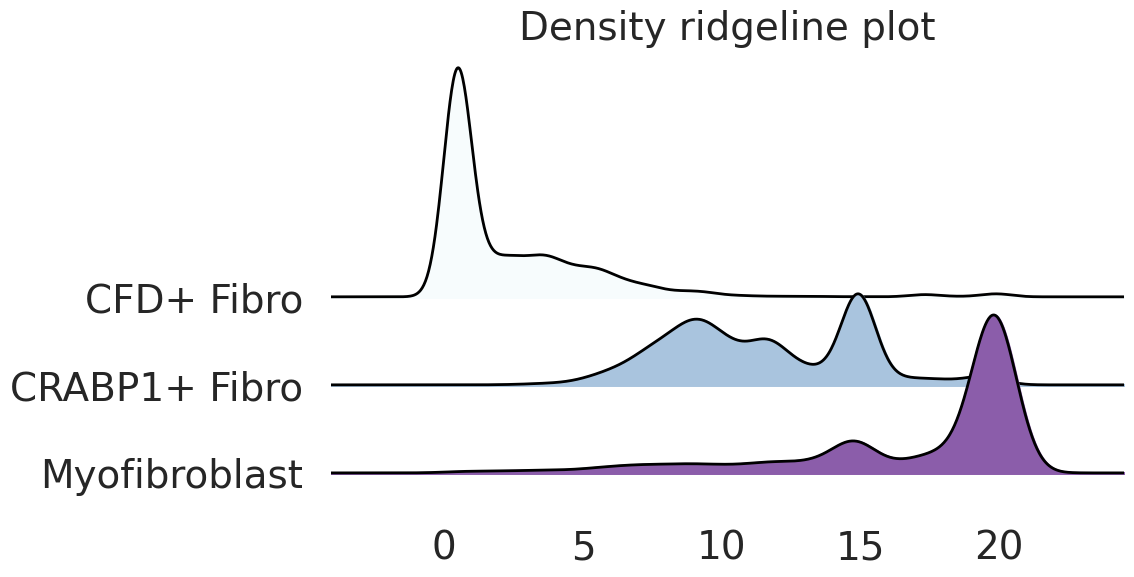

In [87]:
fig, axes = joypy.joyplot(data, by='Fibro_celltype', column='Pseudotime', colormap=plt.cm.BuPu,
                           figsize=(6,3),
                          linewidth=1, legend=False)

plt.title('Density ridgeline plot')
plt.savefig('./figure/pseudotime_ridges_plot.pdf', dpi=500)

In [7]:
plot_df = pd.read_csv('./gene_expression_along_pseudotime.csv', index_col=0) 
col_df = pd.DataFrame(plot_df.columns, index = plot_df.columns, columns=['pseudotime'])
col_df['pseudotime'] = col_df['pseudotime'].astype('float')

In [10]:
from matplotlib.colors import LinearSegmentedColormap
colors =   [ '#6bb46c', '#ffffff',  '#93579f']              
n_bins = [0, 0.5, 1]
cmap_name = 'my_colormap'
cm = LinearSegmentedColormap.from_list(cmap_name, list(zip(n_bins, colors)))

In [11]:
selected_rows = ["CFD", "CRABP1", "FAP", "CTHRC1",  'C3', 'TGFB3', 'BMP1','TGFB1', 'ACTA2', 'BMP1']
label_rows = plot_df.apply(lambda x: x.name if x.name in selected_rows else None,axis=1)

<Figure size 600x650 with 0 Axes>

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


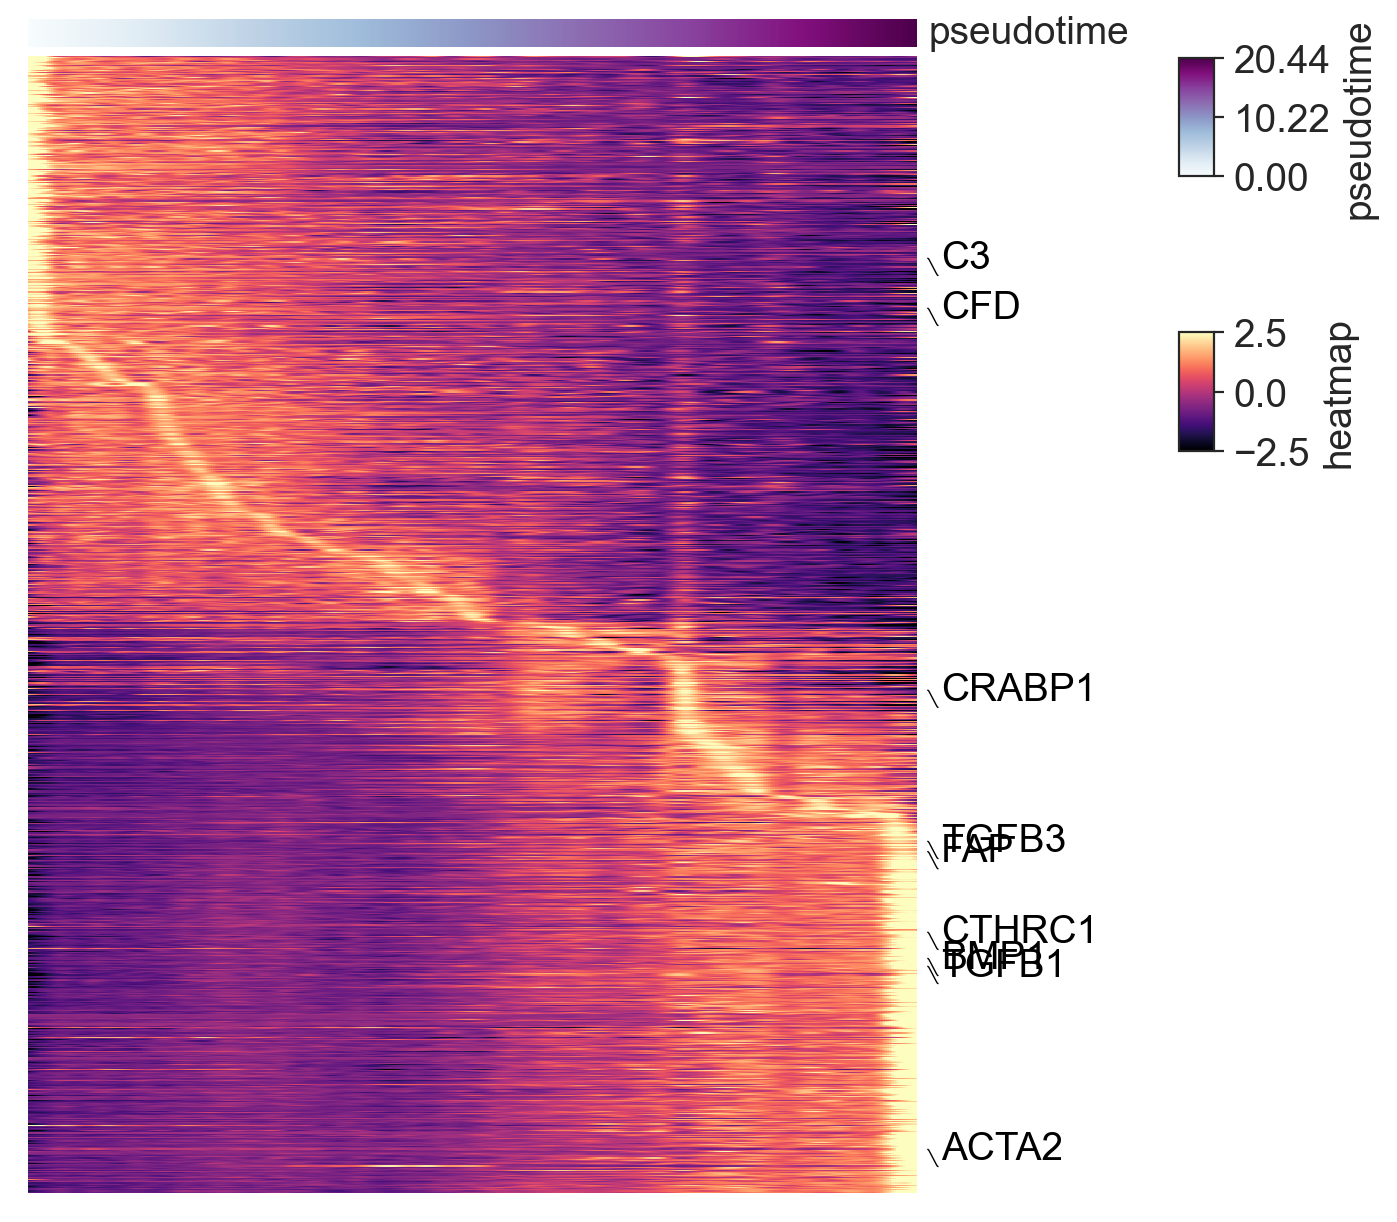

In [13]:
plt.figure(figsize=(6, 6.5))
top_annotation = HeatmapAnnotation(
    pseudotime = anno_simple(col_df['pseudotime'], add_text=False, cmap='BuPu')    #colors 
)

right_annotation =HeatmapAnnotation(
     selected=anno_label(label_rows,colors='black'),verbose=0,orientation='right',
    axis=0)

cm2 =PyComplexHeatmap.ClusterMapPlotter(data=plot_df, z_score=0, 
                                        vmin=-2.5, vmax=2.5, 
                       top_annotation=top_annotation,   
                       right_annotation =right_annotation ,
                       cmap='magma',  #Spectral_r
                       show_rownames=False, 
                       show_colnames=False,
                       col_dendrogram=False, 
                       row_dendrogram=False, 
                       col_cluster=False, 
                       row_cluster=False, 
                       legend_gap=20, legend=True, rasterized=True, 
                     )
plt.savefig('./figure/Heatmap_fibroblast_pseudotime_DEG.pdf', dpi=300)